## Week Three - Assignment Graph Visualization

1. Load a graph database of your choosing from a text file or other source.  If
you take a large network dataset from the web (such as from Stanford Large Network Dataset Collection), please feel free at this point to load just a small subset of the nodes and edges.
2. Create basic analysis on the graph, including the graph’s diameter, and at least one other metric of your choosing.  You may either code the functions by hand (to build your intuition and insight), or use functions in an existing package.
3. Use a visualization tool of your choice (Neo4j, Gephi, etc.) to display information.
4. Please record a short video (~ 5 minutes), and submit a link to the video in advance of our meet-up.

### Introduction

For this assignment, I use NBA game data to create and analyze a network of teams during the 2019–2020 season. Teams are represented as nodes, games as edges, and the number of games between teams as edge weights. I analyze the network using diameter, degree, and degree centrality, then visualize the results.

### Install and import the tools

Here I install and import the necessary libraries for the assignment. I use Pandas to organize and analyze the dataset, KaggleHub to download the dataset, NetworkX to create and analyze the graph where teams are represented as nodes and games as edges, and Matplotlib to visualize the graph. I also use OS to work with file paths and files.

In [36]:
# Install packages
#!pip install -q kagglehub[pandas-datasets] networkx matplotlib pandas

# Import Libraries
import kagglehub
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os
from matplotlib.colors import LinearSegmentedColormap


### Download and load the dataset

Next, I use KaggleHub to download the NBA Games dataset from Kaggle. The dataset contains five csv files, but for this analysis I use games.csv and teams.csv. I load both files into pandas dataframes so I can examine and analyze the data.

The output shows that games.csv contains 26,651 game records and 21 columns, while teams.csv contains 30 teams and 14 columns. The most important columns for the network are HOME_TEAM_ID and VISITOR_TEAM_ID, which identify the teams involved in each game, and TEAM_ID in the teams dataset, which identifies each NBA team. In the network, NBA teams are the nodes and games played between teams are the edges.

In [2]:
# Download NBA Dataset

path = kagglehub.dataset_download("nathanlauga/nba-games")

print("Dataset downloaded to:")
print(path)

# List files in the dataset
import os

print("\nFiles:")
for file in os.listdir(path):
    print(file)

# Load data

games_file = os.path.join(path, "games.csv")
teams_file = os.path.join(path, "teams.csv")

games = pd.read_csv(games_file)
teams = pd.read_csv(teams_file)

print("\nGames dataset shape:", games.shape)
print("Teams dataset shape:", teams.shape)

print("\nGames columns:")
print(games.columns.tolist())

print("\nTeams columns:")
print(teams.columns.tolist())

100%|██████████| 21.2M/21.2M [00:00<00:00, 144MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/nathanlauga/nba-games/versions/10

Files:
games_details.csv
games.csv
ranking.csv
teams.csv
players.csv

Games dataset shape: (26651, 21)
Teams dataset shape: (30, 14)

Games columns:
['GAME_DATE_EST', 'GAME_ID', 'GAME_STATUS_TEXT', 'HOME_TEAM_ID', 'VISITOR_TEAM_ID', 'SEASON', 'TEAM_ID_home', 'PTS_home', 'FG_PCT_home', 'FT_PCT_home', 'FG3_PCT_home', 'AST_home', 'REB_home', 'TEAM_ID_away', 'PTS_away', 'FG_PCT_away', 'FT_PCT_away', 'FG3_PCT_away', 'AST_away', 'REB_away', 'HOME_TEAM_WINS']

Teams columns:
['LEAGUE_ID', 'TEAM_ID', 'MIN_YEAR', 'MAX_YEAR', 'ABBREVIATION', 'NICKNAME', 'YEARFOUNDED', 'CITY', 'ARENA', 'ARENACAPACITY', 'OWNER', 'GENERALMANAGER', 'HEADCOACH', 'DLEAGUEAFFILIATION']


### Preview datasets

Here, we take a preview of the games.csv and teams.csv files. The games.csv dataset contains 26,651 records and 21 columns, including game dates, team IDs, seasons, scores, statistics, and game outcomes. The team identification and outcome fields have no missing values, while 99 records have missing game-statistic values. However, these missing values will not affect the network because I only need the team IDs to identify the connections between teams.

The teams.csv dataset contains 30 NBA teams and 14 columns, including team IDs, names, cities, arenas, and other team information. Most variables are complete, with 4 missing arena-capacity values. The two datasets contain the information needed to construct the network because TEAM_ID in teams.csv can be matched with HOME_TEAM_ID and VISITOR_TEAM_ID in games.csv.

In [3]:
# Preview dataset

file_path = os.path.join(path, "games.csv")

df = pd.read_csv(file_path)

print("Dataset loaded!")
print("Shape:", df.shape)

print("\nFirst 5 records:")
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

print(df.info())
print(df.columns)


# Preview dataset

file_path2 = os.path.join(path, "teams.csv")

df2 = pd.read_csv(file_path2)

print("Dataset loaded!")
print("Shape:", df2.shape)

print("\nFirst 5 records:")
display(df2.head())

print("\nColumns:")
print(df2.columns.tolist())

print(df2.info())
print(df2.columns)



Dataset loaded!
Shape: (26651, 21)

First 5 records:


,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-12-22,22200477,Final,1610612740,1610612759,2022,1610612740,126.0,0.484,0.926,...,25.0,46.0,1610612759,117.0,0.478,0.815,0.321,23.0,44.0,1
1,2022-12-22,22200478,Final,1610612762,1610612764,2022,1610612762,120.0,0.488,0.952,...,16.0,40.0,1610612764,112.0,0.561,0.765,0.333,20.0,37.0,1
2,2022-12-21,22200466,Final,1610612739,1610612749,2022,1610612739,114.0,0.482,0.786,...,22.0,37.0,1610612749,106.0,0.470,0.682,0.433,20.0,46.0,1
3,2022-12-21,22200467,Final,1610612755,1610612765,2022,1610612755,113.0,0.441,0.909,...,27.0,49.0,1610612765,93.0,0.392,0.735,0.261,15.0,46.0,1
4,2022-12-21,22200468,Final,1610612737,1610612741,2022,1610612737,108.0,0.429,1.000,...,22.0,47.0,1610612741,110.0,0.500,0.773,0.292,20.0,47.0,0



Columns:
['GAME_DATE_EST', 'GAME_ID', 'GAME_STATUS_TEXT', 'HOME_TEAM_ID', 'VISITOR_TEAM_ID', 'SEASON', 'TEAM_ID_home', 'PTS_home', 'FG_PCT_home', 'FT_PCT_home', 'FG3_PCT_home', 'AST_home', 'REB_home', 'TEAM_ID_away', 'PTS_away', 'FG_PCT_away', 'FT_PCT_away', 'FG3_PCT_away', 'AST_away', 'REB_away', 'HOME_TEAM_WINS']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26651 entries, 0 to 26650
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   GAME_DATE_EST     26651 non-null  object 
 1   GAME_ID           26651 non-null  int64  
 2   GAME_STATUS_TEXT  26651 non-null  object 
 3   HOME_TEAM_ID      26651 non-null  int64  
 4   VISITOR_TEAM_ID   26651 non-null  int64  
 5   SEASON            26651 non-null  int64  
 6   TEAM_ID_home      26651 non-null  int64  
 7   PTS_home          26552 non-null  float64
 8   FG_PCT_home       26552 non-null  float64
 9   FT_PCT_home       26552 non-null  float64
 10  FG3_

,LEAGUE_ID,TEAM_ID,MIN_YEAR,MAX_YEAR,ABBREVIATION,NICKNAME,YEARFOUNDED,CITY,ARENA,ARENACAPACITY,OWNER,GENERALMANAGER,HEADCOACH,DLEAGUEAFFILIATION
0,0,1610612737,1949,2019,ATL,Hawks,1949,Atlanta,State Farm Arena,18729.0,Tony Ressler,Travis Schlenk,Lloyd Pierce,Erie Bayhawks
1,0,1610612738,1946,2019,BOS,Celtics,1946,Boston,TD Garden,18624.0,Wyc Grousbeck,Danny Ainge,Brad Stevens,Maine Red Claws
2,0,1610612740,2002,2019,NOP,Pelicans,2002,New Orleans,Smoothie King Center,NaN,Tom Benson,Trajan Langdon,Alvin Gentry,No Affiliate
3,0,1610612741,1966,2019,CHI,Bulls,1966,Chicago,United Center,21711.0,Jerry Reinsdorf,Gar Forman,Jim Boylen,Windy City Bulls
4,0,1610612742,1980,2019,DAL,Mavericks,1980,Dallas,American Airlines Center,19200.0,Mark Cuban,Donnie Nelson,Rick Carlisle,Texas Legends



Columns:
['LEAGUE_ID', 'TEAM_ID', 'MIN_YEAR', 'MAX_YEAR', 'ABBREVIATION', 'NICKNAME', 'YEARFOUNDED', 'CITY', 'ARENA', 'ARENACAPACITY', 'OWNER', 'GENERALMANAGER', 'HEADCOACH', 'DLEAGUEAFFILIATION']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LEAGUE_ID           30 non-null     int64  
 1   TEAM_ID             30 non-null     int64  
 2   MIN_YEAR            30 non-null     int64  
 3   MAX_YEAR            30 non-null     int64  
 4   ABBREVIATION        30 non-null     object 
 5   NICKNAME            30 non-null     object 
 6   YEARFOUNDED         30 non-null     int64  
 7   CITY                30 non-null     object 
 8   ARENA               30 non-null     object 
 9   ARENACAPACITY       26 non-null     float64
 10  OWNER               30 non-null     object 
 11  GENERALMANAGER      30 non-null     object 
 12  HEADCOAC

### Prepare the Data and Select the Season

Before creating the network, I cleaned up the NBA dataset a bit so the teams could be clearly identified. The dataset provides each team with a numerical TEAM_ID, along with separate CITY and NICKNAME variabled, so I combined these to create a new TEAM_NAME variable. This gives us recognizable names such as "Boston Celtics" and "Los Angeles Lakers" instead of numerical IDs. I then created a dictionary connecting each team's ID to its name so the network nodes could be labeled appropriately.

The dataset contains multiple NBA seasons ranging from 2003 through 2022. To keep the analysis simpler and make the network easier to interpret, I selected the 2019–2020 season, represented by SEASON = 2019 in the dataset. I filtered the games to this season which resulted in 1,241 games. Limiting the data to one season means that each relationship represents a connection within the same defined period, providing a consistent basis for analyzing the network's diameter, connectivity, and centrality.

In [30]:
# Create team name (the dataset has CITY and NICKNAME rather than actual team name)

teams["TEAM_NAME"] = (
    teams["CITY"].astype(str)
    + " "
    + teams["NICKNAME"].astype(str))

# Change team id to team name
team_names = dict(
    zip(
        teams["TEAM_ID"],
        teams["TEAM_NAME"]
    ))
print("\nTeam names:")

for team_id, name in team_names.items():
    print(team_id, "=", name)

# There are multiple seasons in the dataset and therefore better to choose one for this assignment. Lets see which ones are available.

print("\nAvailable seasons:")

print(
    sorted(
        games["SEASON"].unique()
    ))

# Selecting only one season: We will analyze the 2019-2020 NBA season.
selected_season = 2019
season_games = games[
    games["SEASON"] == selected_season
].copy()

print("\nSelected season:", selected_season)

print(
    "Number of games:",
    len(season_games))


Team names:
1610612737 = Atlanta Hawks
1610612738 = Boston Celtics
1610612740 = New Orleans Pelicans
1610612741 = Chicago Bulls
1610612742 = Dallas Mavericks
1610612743 = Denver Nuggets
1610612745 = Houston Rockets
1610612746 = Los Angeles Clippers
1610612747 = Los Angeles Lakers
1610612748 = Miami Heat
1610612749 = Milwaukee Bucks
1610612750 = Minnesota Timberwolves
1610612751 = Brooklyn Nets
1610612752 = New York Knicks
1610612753 = Orlando Magic
1610612754 = Indiana Pacers
1610612755 = Philadelphia 76ers
1610612756 = Phoenix Suns
1610612757 = Portland Trail Blazers
1610612758 = Sacramento Kings
1610612759 = San Antonio Spurs
1610612760 = Oklahoma City Thunder
1610612761 = Toronto Raptors
1610612762 = Utah Jazz
1610612763 = Memphis Grizzlies
1610612764 = Washington Wizards
1610612765 = Detroit Pistons
1610612766 = Charlotte Hornets
1610612739 = Cleveland Cavaliers
1610612744 = Golden State Warriors

Available seasons:
[np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), 

### Construct the Weighted NBA Network

After selecting the 2019–2020 NBA season, I transform the game data into a network using NetworkX. I define the NBA teams as nodes and games between teams as edges. I use an undirected graph because the relationship between two teams is mutual, regardless of which team is home or visiting.

I also created a weighted network where the edge weight shows how many times two teams played each other. The code looks at each game and creates a connection between the two teams. If the same teams play again, instead of creating a new connection, the code adds 1 to the existing connection. For example, if the Celtics and Raptors played four times, they have one connection with a weight of 4. This keeps the network from having four separate lines between the same teams while still showing how often they played.

I then check the resulting graph to make sure it was constructed correctly. The dataset contains 1,241 games and 1,241 unique game IDs, and the total edge weight is also 1,241, confirming that each game is represented once. The network contains 30 teams and 431 unique connections. The difference between the number of games and connections occurs because teams played each other multiple times. The graph is also connected, meaning every team can be reached from every other team. As a final check, I looked at the sample weighted connections, such as the Miami Heat playing the Boston Celtics 9 times and the Los Angeles Lakers, Milwaukee Bucks, and Indiana Pacers 8 times each.

In [33]:
# Create weighted graph

# Network definition: Nodes = NBA teams, Edges = games between teams, Edge weight = number of games played between two teams
# The graph is undirected because the relationship between Team A and Team B is mutual.

G = nx.Graph()

for _, game in season_games.iterrows():

    home_id = game["HOME_TEAM_ID"]
    away_id = game["VISITOR_TEAM_ID"]

    # Convert team IDs into team names

    home_team = team_names.get(home_id)
    away_team = team_names.get(away_id)

    # Add edge if both teams are found
    if home_team and away_team:
        # Teams with an edge: increased the number of games between them.
        if G.has_edge(home_team, away_team):
            G[home_team][away_team]["weight"] += 1
        # Otherwise create a new edge with weight = 1.
        else:
            G.add_edge(
                home_team,
                away_team,
                weight=1)

print("season_games rows:", len(season_games))
print("\nUnique game IDs:", season_games["GAME_ID"].nunique())
print("\nGame seasons:")
print(season_games["SEASON"].value_counts())

print("\nTotal edge weight:", sum(
    data["weight"]
    for _, _, data in G.edges(data=True)
))

# Add graph info
print("\n")
print("Graph Info")

print(
    "Number of teams:",
    G.number_of_nodes())
print(
    "Number of connections:",
    G.number_of_edges())
print(
    "Total games represented:",
    sum(
        data["weight"]
        for _, _, data in G.edges(data=True)
    ))
print(
    "Graph connected?:",
    nx.is_connected(G))

# Include sample weighted connections
print("\n")
print("Weighted Connections")

for u, v, data in list(
    G.edges(data=True)
)[:15]:

    print(
        f"{u} -- {v}: "
        f"{data['weight']} games")

season_games rows: 1241

Unique game IDs: 1241

Game seasons:
SEASON
2019    1241
Name: count, dtype: int64

Total edge weight: 1241


Graph Info
Number of teams: 30
Number of connections: 431
Total games represented: 1241
Graph connected?: True


Weighted Connections
Miami Heat -- Los Angeles Lakers: 8 games
Miami Heat -- Boston Celtics: 9 games
Miami Heat -- Milwaukee Bucks: 8 games
Miami Heat -- Indiana Pacers: 8 games
Miami Heat -- Oklahoma City Thunder: 2 games
Miami Heat -- Phoenix Suns: 2 games
Miami Heat -- Toronto Raptors: 3 games
Miami Heat -- Denver Nuggets: 2 games
Miami Heat -- Memphis Grizzlies: 3 games
Miami Heat -- Utah Jazz: 3 games
Miami Heat -- Sacramento Kings: 3 games
Miami Heat -- Charlotte Hornets: 3 games
Miami Heat -- Washington Wizards: 4 games
Miami Heat -- New Orleans Pelicans: 2 games
Miami Heat -- Orlando Magic: 5 games


### Analyze Data: Network Diameter and Degree

Since the NBA network has been constructed, I can now analyze its structure. The first metric I used was graph diameter, which tells us the greatest shortest distance between any two teams. The network is connected, and the diameter is 2, meaning that any team can reach any other team either directly or through just one other team. I also examine degree, which tells us how many different teams each team played during the 2019–2020 season. Since there are 30 teams, the maximum possible degree is 29. The results show that 25 teams have a degree of 29, four teams have a degree of 28, and the Cleveland Cavaliers have a degree of 27.

These results show that the NBA network was highly connected during the selected season. Almost every team played almost every other team, and even teams without a direct connection could reach each other through only one intermediate team. This is reflected in the high degree values and the diameter of 2.

In [34]:
# Graph diatmeter
# Diameter measures the longest shortest path between any two nodes in the network.

if nx.is_connected(G):

    diameter = nx.diameter(G)

    print(
        "Graph Diameter:",
        diameter)

else:
    # If the graph is disconnected, calculate the diameter of the largest connected component.
    largest_component = max(
        nx.connected_components(G),
        key=len)

    largest_subgraph = G.subgraph(
        largest_component
    ).copy()

    diameter = nx.diameter(
        largest_subgraph)

    print(
        "Graph disconnected.")
    print(
        "Using the largest connected component.")
    print(
        "Largest component size:",
        largest_subgraph.number_of_nodes())
    print(
        "Graph Diameter:",
        diameter)

# Add degree
print("\n")
print("Team Degree")

# Degree (number of other teams directly connected to each team).

degrees = dict(
    G.degree())

sorted_degrees = sorted(
    degrees.items(),
    key=lambda x: x[1],
    reverse=True)

for team, degree in sorted_degrees:

    print(
        f"{team}: {degree} connections")

Graph Diameter: 2


TEAM DEGREE
Miami Heat: 29 connections
Los Angeles Lakers: 29 connections
Boston Celtics: 29 connections
Los Angeles Clippers: 29 connections
Houston Rockets: 29 connections
Toronto Raptors: 29 connections
Milwaukee Bucks: 29 connections
Oklahoma City Thunder: 29 connections
Utah Jazz: 29 connections
Dallas Mavericks: 29 connections
Orlando Magic: 29 connections
Portland Trail Blazers: 29 connections
Indiana Pacers: 29 connections
Philadelphia 76ers: 29 connections
Brooklyn Nets: 29 connections
Memphis Grizzlies: 29 connections
Washington Wizards: 29 connections
San Antonio Spurs: 29 connections
New Orleans Pelicans: 29 connections
Detroit Pistons: 29 connections
Atlanta Hawks: 29 connections
Charlotte Hornets: 29 connections
Golden State Warriors: 29 connections
Denver Nuggets: 28 connections
Sacramento Kings: 28 connections
Phoenix Suns: 28 connections
New York Knicks: 28 connections
Chicago Bulls: 28 connections
Minnesota Timberwolves: 28 connections
Cleveland Ca

### Analyze Data: Degree Centrality

After calculating degree, I use degree centrality to show how connected each team is compared with the maximum possible connections. Since there are 30 teams, each team can have a maximum of 29 direct connections. The results show that 23 teams have a degree centrality of 1.000, meaning they are connected to all 29 other teams. Six teams have lower values: the Denver Nuggets, Sacramento Kings, Phoenix Suns, New York Knicks, Chicago Bulls, and Minnesota Timberwolves have 0.966, while the Cleveland Cavaliers have 0.931.

I sorted the results from highest to lowest to compare the teams. Degree centrality counts the number of different teams a team is connected to, not the number of games played. If two teams played multiple games, that still counts as one connection, while the number of games is represented by the edge weight. Therefore, degree centrality shows how broadly each team is connected within the network.

In [29]:
# Degree centrality
print("Degree Centrality")
# Degree centrality is how connected each node is relative to the maximum possible number of connections.
degree_centrality = nx.degree_centrality(G)

sorted_centrality = sorted(
    degree_centrality.items(),
    key=lambda x: x[1],
    reverse=True)

for team, value in sorted_centrality:
    print(
        f"{team}: {value:.3f}")

Degree Centrality
Miami Heat: 1.000
Los Angeles Lakers: 1.000
Boston Celtics: 1.000
Los Angeles Clippers: 1.000
Houston Rockets: 1.000
Toronto Raptors: 1.000
Milwaukee Bucks: 1.000
Oklahoma City Thunder: 1.000
Utah Jazz: 1.000
Dallas Mavericks: 1.000
Orlando Magic: 1.000
Portland Trail Blazers: 1.000
Indiana Pacers: 1.000
Philadelphia 76ers: 1.000
Brooklyn Nets: 1.000
Memphis Grizzlies: 1.000
Washington Wizards: 1.000
San Antonio Spurs: 1.000
New Orleans Pelicans: 1.000
Detroit Pistons: 1.000
Atlanta Hawks: 1.000
Charlotte Hornets: 1.000
Golden State Warriors: 1.000
Denver Nuggets: 0.966
Sacramento Kings: 0.966
Phoenix Suns: 0.966
New York Knicks: 0.966
Chicago Bulls: 0.966
Minnesota Timberwolves: 0.966
Cleveland Cavaliers: 0.931


### Visualizing the NBA Network

After completing the network analysis, I created a visualization using NetworkX and Matplotlib. The node size represents degree, with larger nodes indicating teams with more direct connections. Node color represents degree centrality, using different shades of purple. The edge thickness represents weight, meaning thicker edges indicate teams that played each other more frequently. Team names are displayed as labels, and a color bar shows the degree-centrality scale.

The final network represents the 2019–2020 NBA season and contains 30 teams, 431 unique team-to-team connections, and 1,241 games. The network is connected, with a graph diameter of 2 and an average degree of 28.73. The graph diameter of 2 means that the greatest shortest distance between any two teams is two connections, while the average degree of 28.73 means that teams had a large number of direct connections to other teams.

The plot shows that the 2019–20 NBA schedule formed a very dense network, with nearly every team connected directly to almost every other team. The similar node sizes and mostly dark-purple colors show that degree and degree centrality were high and fairly similar across teams. The thicker edges show that some team pairs played each other more frequently, creating stronger connections within the network. Overall, the league was highly interconnected with little separation between teams, which is consistent with the diameter of 2 and average degree of 28.73.


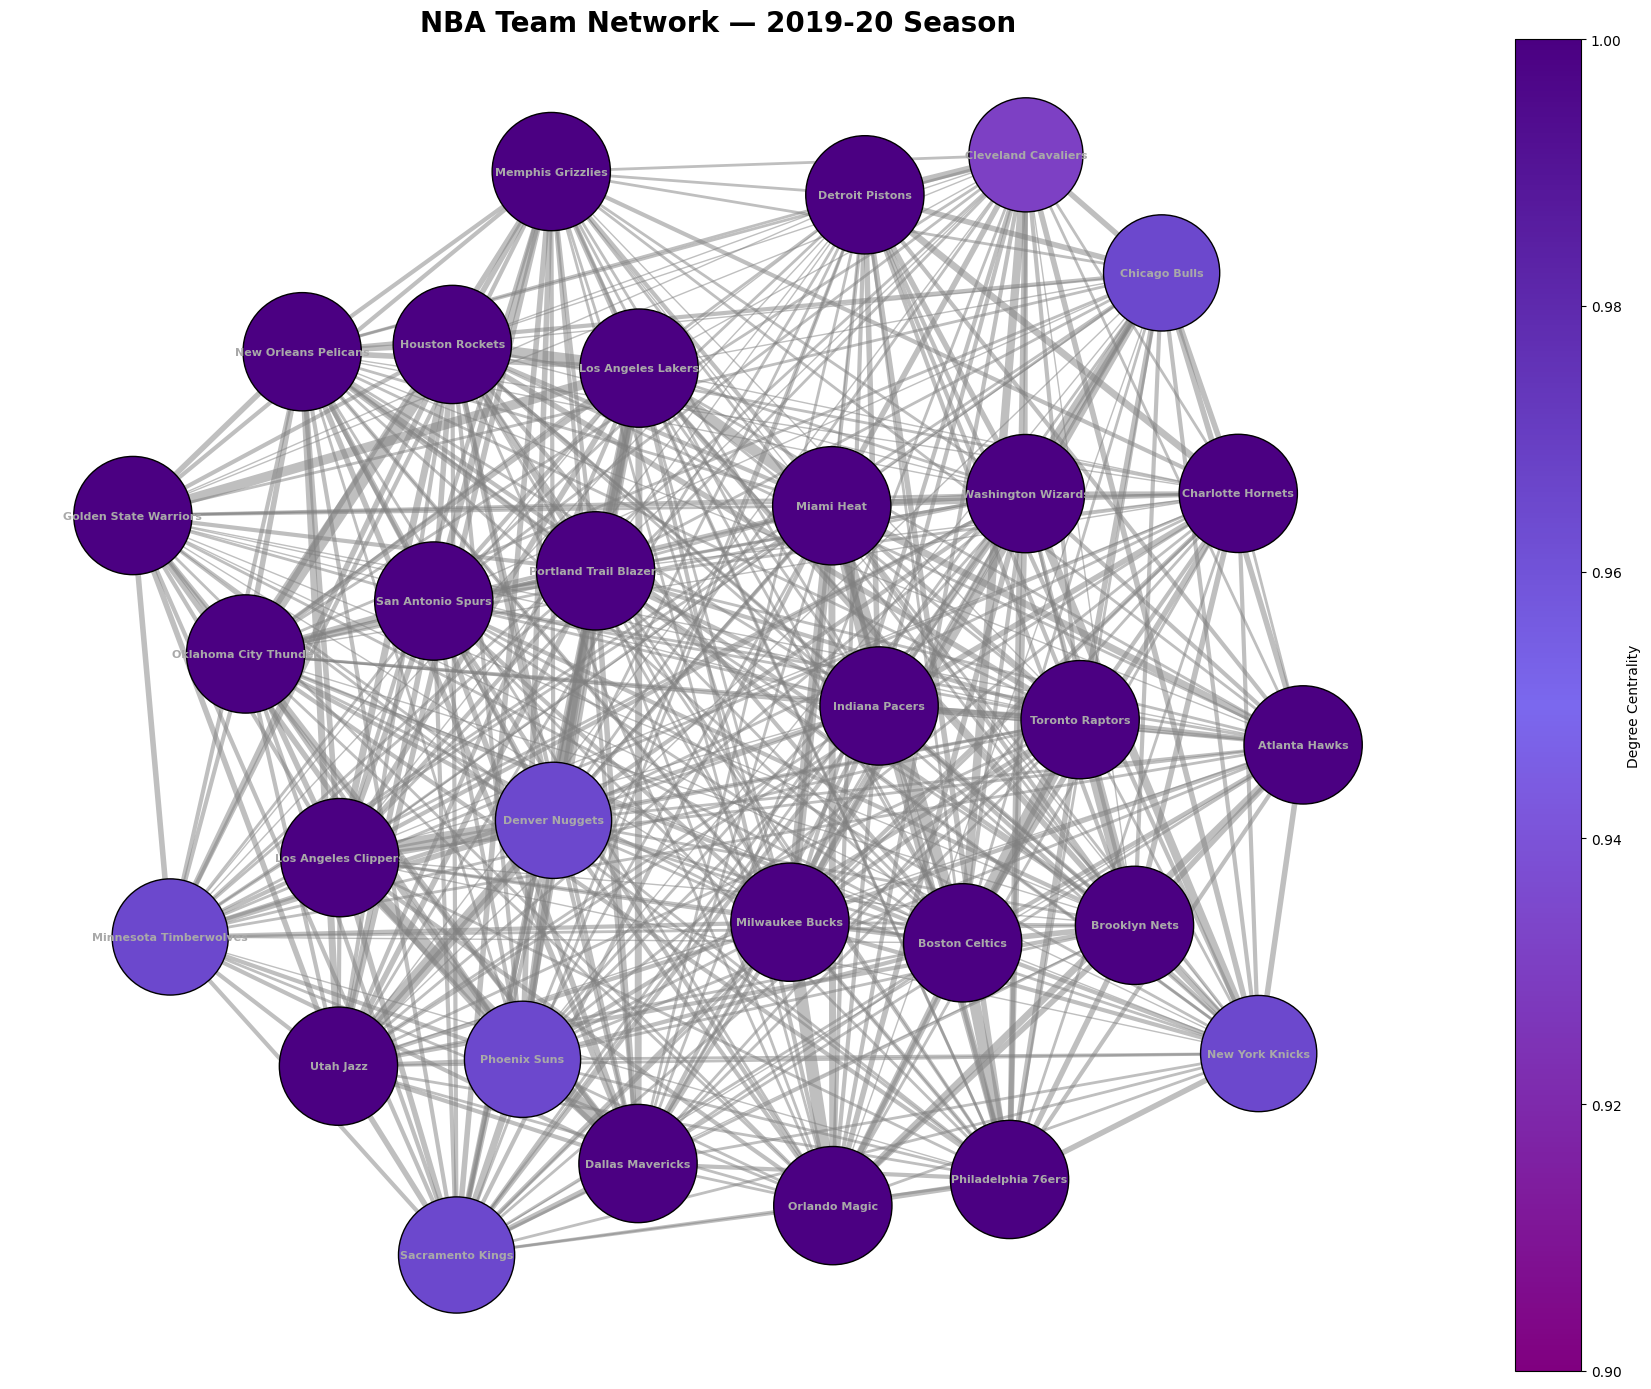



Network Summary
Season: 2019-20
Number of teams: 30
Number of team-to-team connections: 431
Total games represented: 1241
Network connected: True
Diameter: 2
Average degree: 28.73


In [35]:
# Visualize
plt.figure(
    figsize=(18, 14))

# Create graph layout
pos = nx.spring_layout(
    G,
    seed=42,
    k=0.8)

# Node size
# Larger nodes means these teams have more direct connections (degree).
node_sizes = [
    degrees[node] * 250
    for node in G.nodes()
]

# Node color
# Darker purple represents higher degree centrality.
purples = LinearSegmentedColormap.from_list(
    "purples",
    [
        "purple",
        "mediumslateblue",
        "indigo"
    ])

node_colors = [
    degree_centrality[node]
    for node in G.nodes()
]

# Edge width
edge_widths = [
    G[u][v]["weight"]
    for u, v in G.edges()
]

# Edges
nx.draw_networkx_edges(
    G,
    pos,
    edge_color="gray",
    alpha=0.5,
    width=edge_widths)

# Nodes
nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=purples,
    vmin=0.90,
    vmax=1.00,
    edgecolors="black",
    linewidths=1)

# Team names
nx.draw_networkx_labels(
    G,
    pos,
    font_size=8,
    font_weight="bold",
    font_color="darkgray")

# Bar color
plt.colorbar(
    nodes,
    label="Degree Centrality")

# Title
plt.title(
    f"NBA Team Network — "
    f"{selected_season}-{str(selected_season + 1)[-2:]} Season",
    fontsize=20,
    fontweight="bold")
plt.axis("off")
plt.tight_layout()


# Save image
plt.savefig(
    "nba_team_network.png",
    dpi=300,
    bbox_inches="tight")

# Show graph
plt.show()
# Graph using Gephi
# The GEXF file preserves the edge weights in Gephi

nx.write_gexf(
    G,
    "nba_team_network.gexf")

# Measures
print("\n")
print("Network Summary")

print(
    "Season:",
    f"{selected_season}-{str(selected_season + 1)[-2:]}")
print(
    "Number of teams:",
    G.number_of_nodes())
print(
    "Number of team-to-team connections:",
    G.number_of_edges())
print(
    "Total games represented:",
    sum(
        data["weight"]
        for _, _, data in G.edges(data=True)
    ))
print(
    "Network connected:",
    nx.is_connected(G))
print(
    "Diameter:",
    diameter)
print(
    "Average degree:",
    round(
        sum(degrees.values()) / len(degrees),
        2
    ))


### Conclusion

In this assignment, I learned how to transform a real world dataset into a network by representing NBA teams as nodes and games as edges. The results and plot showed that the 2019–2020 NBA network was highly connected with similar node sizes and colors, a diameter of 2, and average degree of 28.73 which showed that most teams had direct connections with nearly every other team.

I learned that different network measures provide different perspectives on the same network. Degree and degree centrality helped me understand how connected individual teams were, while diameter showed the overall distance between teams. Using weighted edges also showed me that a connection can represent not only whether a relationship exists but how frequently that relationship occurs. This helped me understand how network analysis can reveal patterns and relationships in real world data that may not be as obvious when looking at the original game records alone.